<font color="#CA0032"><h1 align="left">**Dataset completo de competición Rossmann de Kaggle**</h1></font>

https://www.kaggle.com/competitions/rossmann-store-sales/data?select=store.csv</h1></font>

Descargado de:

https://github.com/sarthaksoni25/Rossmann-Store-Sales-Prediction/tree/master/dataset

El objetivo del ejercicio es construir un modelo de predicción de ventas en las siguientes 10 tiendas:

* 1,2,3,4,5,562,682,733,769

El objetivo es obtener en test el mayor $R^2$ posible.

El conjunto de test serán los datos a partir del 1 de enero de 2015 (incluido).

No se podrá usar como variable de entrada la variable "Customers".


### **Usaremos un esquema many to one:**

<img src="https://drive.google.com/uc?export=download&id=1iokh576AiK2iFhftPogSBsNXixAi-LBg" align="center" style="float" width="500">

In [ ]:
COLAB = True

## <font color="#CA3532"> **1. Importar librerías**

In [ ]:
import numpy as np
import pandas as pd

from keras.models import Sequential, load_model
from keras.layers import Dense, LSTM, GRU
from keras.callbacks import ModelCheckpoint

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score as R2_score

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import os

# fijo la semilla aleatoria por reproducibilidad
np.random.seed(7)

## <font color="#CA3532"> **2. Carga de datos**

In [ ]:
!ls

sample_data


In [ ]:
def download_file_from_google_drive(file_id, dest_file, unzip=False):
  aux = "'https://drive.usercontent.google.com/download?id={}&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280'".format(file_id)
  !wget $aux -O $dest_file
  if unzip:
    !unzip -qq -o $dest_file
    !rm $dest_file

In [ ]:
if COLAB:
    download_file_from_google_drive(file_id='19C18QXw0VtfBm_k6fqaI_nf1RH1Larw1',
                                    dest_file='./store.csv')
    download_file_from_google_drive(file_id='1tg-VNN-s8PwE0eOY6TjjQ5-Orv8kPAqB',
                                    dest_file='./train.csv')

store_data = pd.read_csv('./store.csv')
train_data = pd.read_csv('./train.csv')

--2026-05-28 18:04:53--  https://drive.usercontent.google.com/download?id=19C18QXw0VtfBm_k6fqaI_nf1RH1Larw1&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.219.132, 2607:f8b0:400c:c0d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.219.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45010 (44K) [application/octet-stream]
Saving to: ‘./store.csv’

./store.csv         100%[===================>]  43.96K  --.-KB/s    in 0s      

2026-05-28 18:04:54 (98.5 MB/s) - ‘./store.csv’ saved [45010/45010]

--2026-05-28 18:04:54--  https://drive.usercontent.google.com/download?id=1tg-VNN-s8PwE0eOY6TjjQ5-Orv8kPAqB&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.219.132, 2607:f8b0:400c:c0d::84
Connecting to drive.usercontent.google.com 

/tmp/ipykernel_1011/1423722823.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv('./train.csv')


In [ ]:
store_data

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
train_data = train_data.sort_values(["Date", "Store"])
train_data

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
1000485,1,2,2013-01-01,0,0,0,0,a,1,690197
1000486,2,2,2013-01-01,0,0,0,0,a,1,768084
1000487,3,2,2013-01-01,0,0,0,0,a,1,170743
1000488,4,2,2013-01-01,0,0,0,0,a,1,887832
1000489,5,2,2013-01-01,0,0,0,0,a,1,753407
...,...,...,...,...,...,...,...,...,...,...
1110,1111,5,2015-07-17,4644,383,1,1,0,1,334782
1111,1112,5,2015-07-17,8266,694,1,1,0,1,379399
1112,1113,5,2015-07-17,7740,737,1,1,0,0,150552
1113,1114,5,2015-07-17,23473,3592,1,1,0,1,783000


In [ ]:
store_ids = train_data["Store"].unique()
store_ids

array([   1,    2,    3, ..., 1114, 1115,  988])

In [ ]:
[1,2,3,4,5,562,682,733,769]

[1, 2, 3, 4, 5, 562, 682, 733, 769]

In [ ]:
for store_id in store_ids:
  aux = train_data[train_data["Store"]==store_id]["Sales"]
  if sum(aux==0)==0:
    print(store_id)

85
262
335
423
494
562
682
733
769
1097


In [ ]:
store_ids[-10:]

array([1107, 1108, 1109, 1110, 1111, 1112, 1113, 1114, 1115,  988])

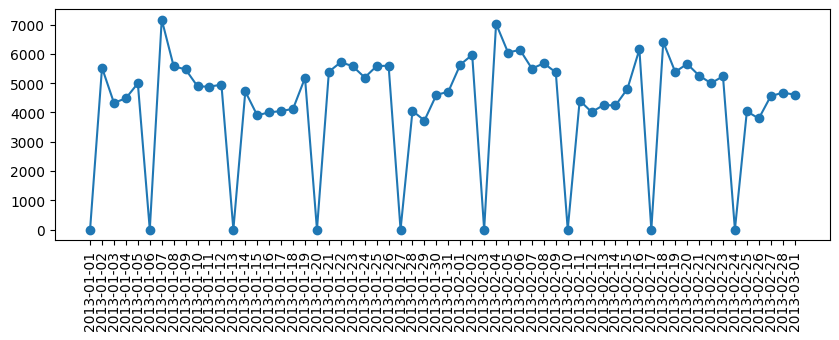

928


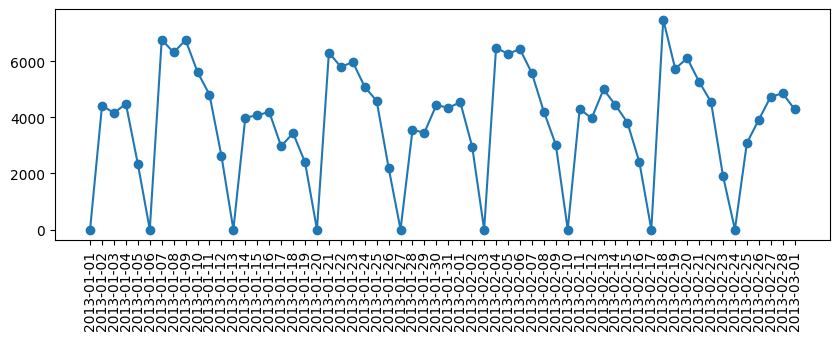

928


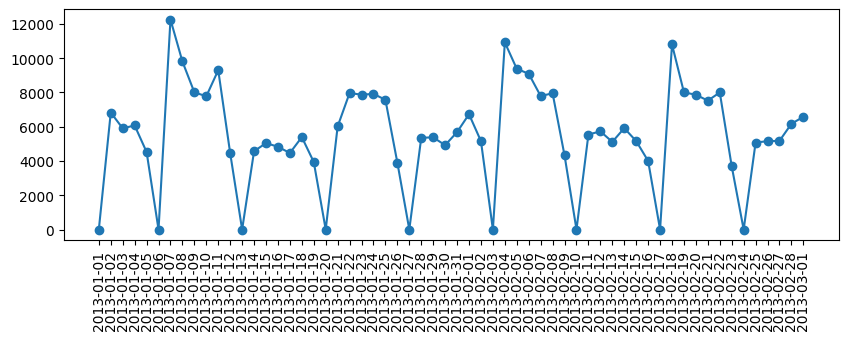

928


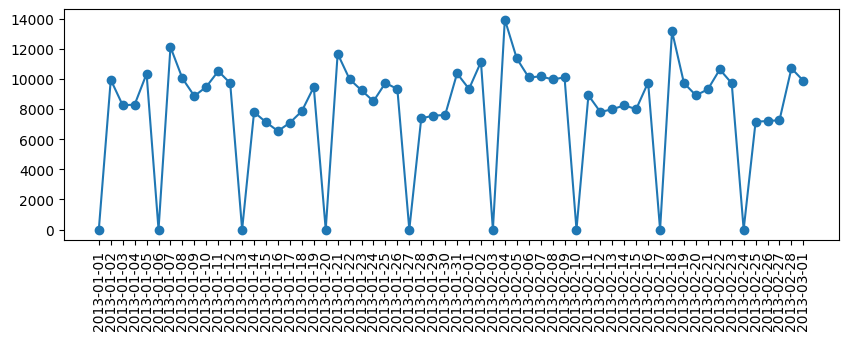

928


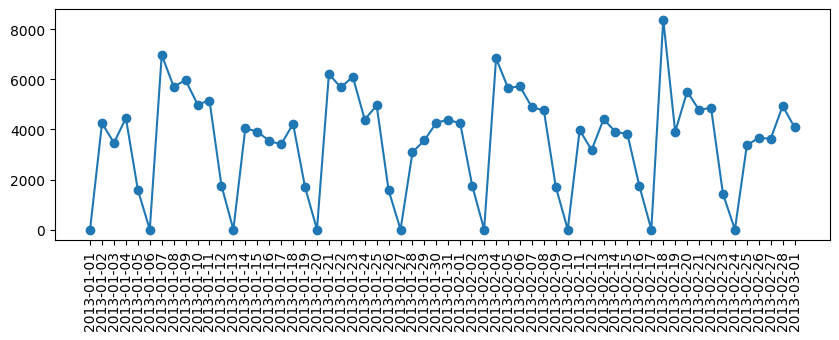

928


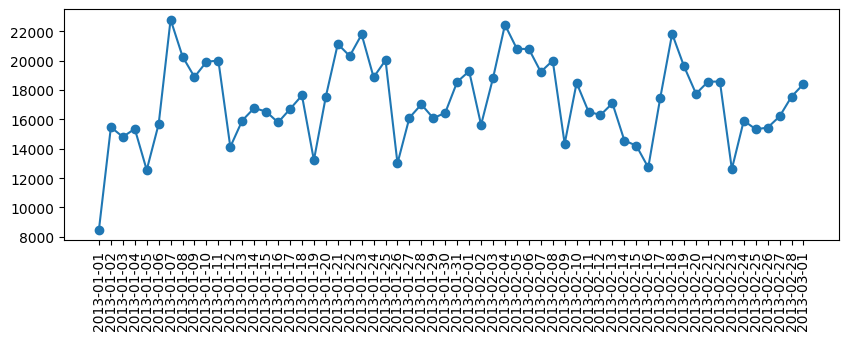

928


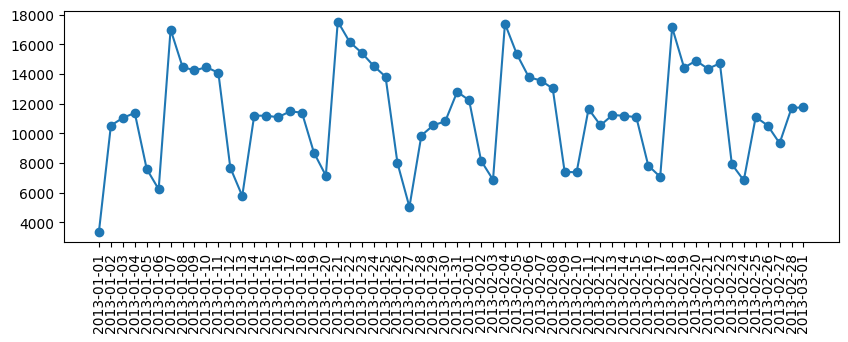

928


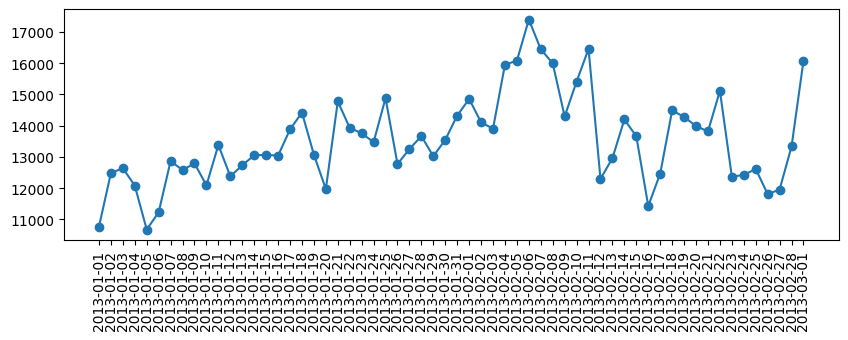

928


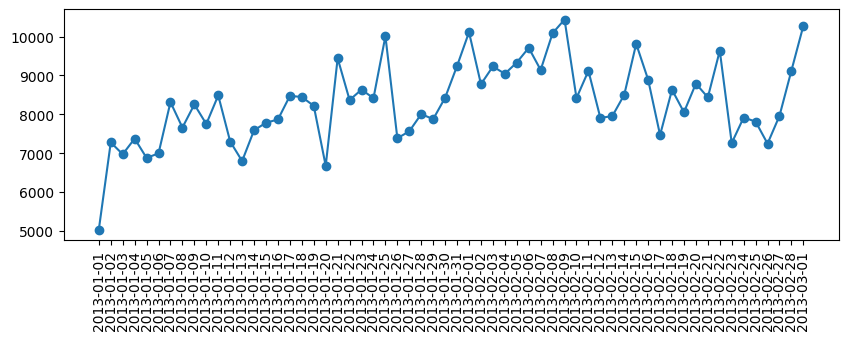

928


In [ ]:
#for store_id in store_ids[:10]:
for store_id in [1,2,3,4,5,562,682,733,769]:
  aux = train_data[train_data["Store"]==store_id]
  plt.figure(figsize=(10,3))
  plt.plot(aux["Date"][:60], aux["Sales"][:60], "o-")
  plt.xticks(rotation=90)
  plt.show()
  print(len(aux))